# Displaced Voices: Eviction Patterns in Maricopa County, AZ

This notebook analyzes 2024 eviction filings across Maricopa County census tracts by integrating U.S. Census ACS 5-Year demographic data with eviction records. Data pipeline functions are in `census_data.py`.

**Analysis flow:**
1. Descriptive statistics — income, ethnicity, rent burden, housing structure
2. K-means clustering of census tracts
3. Cluster-level visualizations
4. Collinearity analysis
5. Count regression models (Poisson and Negative Binomial, with cluster as a fixed effect)
6. Final model and interpretation

In [107]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from census_data import build_full_dataset

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.max_columns', None)


In [108]:
fullDataset = build_full_dataset(year='2023', state='04', county='013')
print(f'Tracts: {fullDataset.shape[0]}  |  Total eviction filings: {fullDataset["filedEviction"].sum():,} | Number of Columns: {fullDataset.shape[1]}')
fullDataset.head()


Tracts: 1533  |  Total eviction filings: 52,877 | Number of Columns: 30


,GeoID,zip_code,filedEviction,medianIncome,state,county,tract,incomeLevel,Single-family homes,Small multi-unit buildings (2-4 units),Larger apartment complexes (5+ units),"Mobile homes, boats, RVs, etc.",majorHouseType,lowBurdan,moderateBurdan,costBurdan,highBurdan,burden,OwnerOccupied,RenterOccupied,LiveType,White Alone,Black Alone,Hispanic or Latino,American Indian or Alaska Native Alone,Asian Alone,Native Hawaiian or Pacific Islander Alone,Some other race,"Mixed race (exluding ""Some other race"")",Majority
0,04013010102,85331,1,188486,04,013,010102,Very High,0.967068,0.0,0.000000,0.000000,Single-family homes,0.763441,0.0,0.000000,0.000000,lowBurdan,0.921170,0.078830,OwnerOccupied,0.916840,0.005427,0.085874,0.0,0.012291,0.0,0.002235,0.020910,White Alone
1,04013010103,85262,1,117813,04,013,010103,Very High,0.890501,0.0,0.017150,0.049472,Single-family homes,0.815385,0.0,0.000000,0.000000,lowBurdan,0.969030,0.030970,OwnerOccupied,0.918229,0.003803,0.076881,0.0,0.000000,0.0,0.004890,0.057865,White Alone
2,04013010104,N/A,0,140587,04,013,010104,Very High,0.967761,0.0,0.000000,0.000000,Single-family homes,0.000000,0.0,0.196429,0.000000,costBurdan,0.968061,0.031939,OwnerOccupied,0.955605,0.000000,0.010220,0.0,0.007027,0.0,0.000000,0.025232,White Alone
3,04013030401,85331,1,145865,04,013,030401,Very High,0.904664,0.0,0.011969,0.000000,Single-family homes,0.188119,0.0,0.217822,0.321782,highBurdan,0.930886,0.069114,OwnerOccupied,0.912521,0.005691,0.017707,0.0,0.025295,0.0,0.000000,0.043634,White Alone
4,04013030401,85377,1,145865,04,013,030401,Very High,0.904664,0.0,0.011969,0.000000,Single-family homes,0.188119,0.0,0.217822,0.321782,highBurdan,0.930886,0.069114,OwnerOccupied,0.912521,0.005691,0.017707,0.0,0.025295,0.0,0.000000,0.043634,White Alone


## 1. Descriptive Statistics

Overview of income distribution, racial/ethnic composition, rent burden, and housing structure across all Maricopa County tracts.

### plots

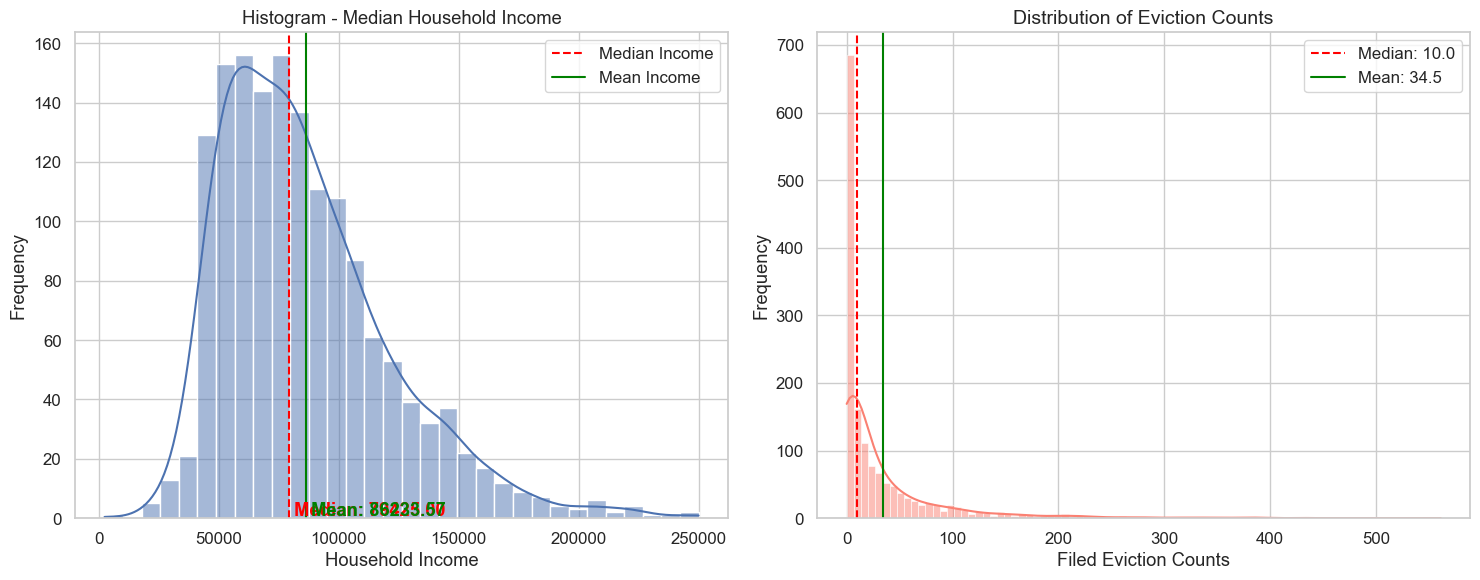

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=fullDataset, x='medianIncome', kde=True, ax = axes[0])

Income_median = fullDataset['medianIncome'].median()
Income_mean = fullDataset['medianIncome'].mean()

axes[0].axvline(x=Income_median, color='red', linestyle='--', label='Median Income')
axes[0].axvline(x=Income_mean, color='green', linestyle='solid', label='Mean Income')

axes[0].text(Income_median, plt.gca().get_ylim()[1]*0.9, f' Median: {Income_median:.2f}', color='red', fontweight='bold')
axes[0].text(Income_mean, plt.gca().get_ylim()[1]*0.8, f' Mean: {Income_mean:.2f}', color='green', fontweight='bold')
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Household Income")
axes[0].legend()
axes[0].set_title("Histogram - Median Household Income")

sns.histplot(data=fullDataset, x='filedEviction', kde=True, ax=axes[1], color='salmon')
Eviction_median = fullDataset['filedEviction'].median()
Eviction_mean = fullDataset['filedEviction'].mean()
axes[1].axvline(Eviction_median, color='red', linestyle='--', label=f'Median: {Eviction_median:.1f}')
axes[1].axvline(Eviction_mean, color='green', linestyle='solid', label=f'Mean: {Eviction_mean:.1f}')
axes[1].set_title('Distribution of Eviction Counts', fontsize=14)
axes[1].set_ylabel("Frequency")
axes[1].set_xlabel("Filed Eviction Counts")
axes[1].legend()

plt.tight_layout()
plt.show()

Histogram indicates that house income in tracts is right skewness as median less than mean and eviction count is right skew as well. 

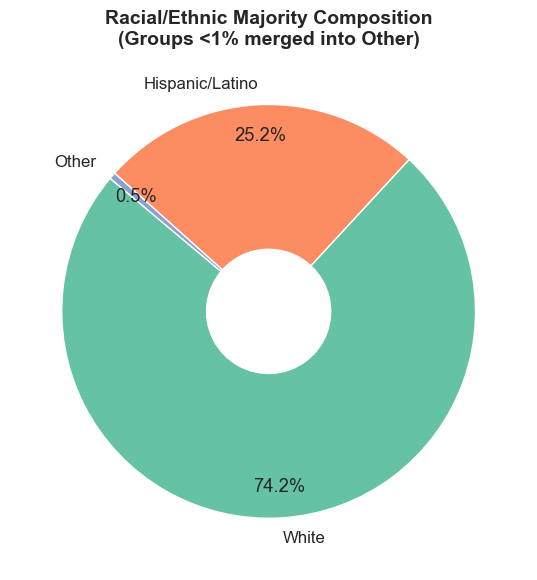

In [110]:
majority_counts = fullDataset['Majority'].value_counts()
short_labels_map = {
    'White Alone': 'White',
    'Hispanic or Latino': 'Hispanic/Latino',
    'Black Alone': 'Black',
    'Asian Alone': 'Asian',
    'American Indian or Alaska Native Alone': 'Native American',
    'Native Hawaiian or Pacific Islander Alone': 'Pacific Islander',
    'Some other race': 'Other',
    'Mixed race (exluding "Some other race")': 'Mixed',
}

majority_counts.index = [short_labels_map.get(l, l) for l in majority_counts.index]

threshold = 0.01
total = majority_counts.sum()
mask = (majority_counts / total) < threshold

other_sum = majority_counts[mask].sum()

new_counts = majority_counts[~mask].copy()

if other_sum > 0:
    if 'Other' in new_counts:
        new_counts['Other'] += other_sum
    else:
        new_counts['Other'] = other_sum

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    new_counts.values,
    labels=new_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(new_counts)),
    pctdistance=0.85,
    wedgeprops={'width': 0.7, 'edgecolor': 'w'}
)

ax.set_title('Racial/Ethnic Majority Composition\n(Groups <1% merged into Other)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In pie chart, Maricopa county in Arizona, major ethic composition is white and Hispanic/Latino. 

### Ordinal Burden level and median income and eviction level

In [111]:
burden_order = ['lowBurdan', 'moderateBurdan', 'costBurdan', 'highBurdan']

fullDataset['burden'] = pd.Categorical(fullDataset['burden'], categories=burden_order)

eviction_burden = fullDataset.groupby('burden', as_index=True)['filedEviction'].agg([
    'count',
    'mean',
    'median',
    'sum'
])

total_evictions = fullDataset['filedEviction'].sum()
eviction_burden['percent_of_total_evictions'] = (income_burden['sum'] / total_evictions * 100).round(1)

print(eviction_burden)

                count       mean  median    sum  percent_of_total_evictions
burden                                                                     
lowBurdan          53   9.094340     4.0    482                         0.9
moderateBurdan    323  22.179567     8.0   7164                        13.5
costBurdan        884  39.532805    12.0  34947                        66.1
highBurdan        273  37.670330     8.0  10284                        19.4


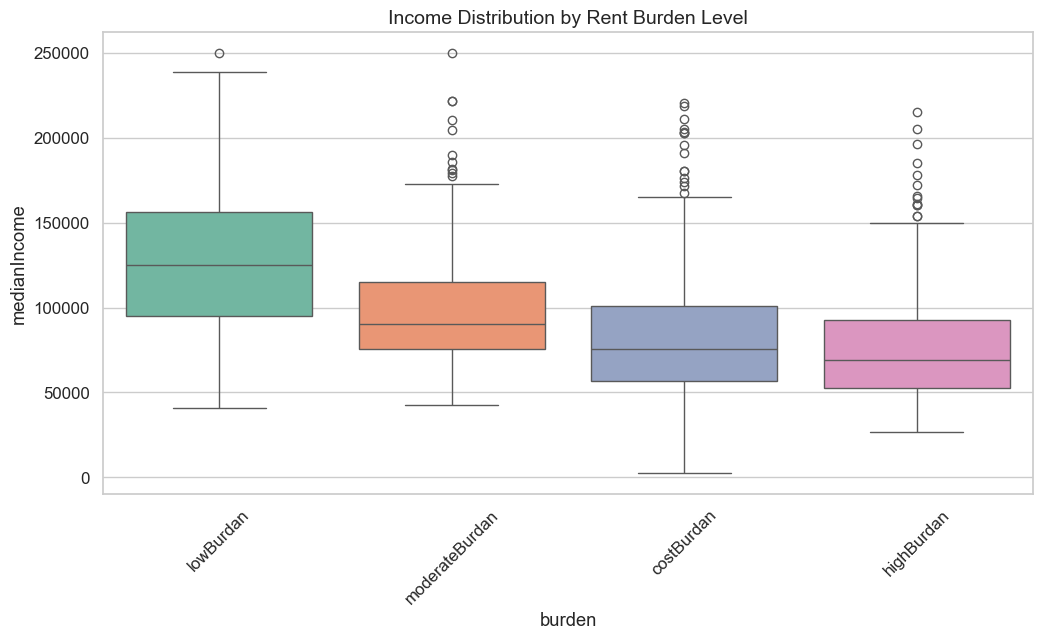

In [112]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=fullDataset, x='burden', y='medianIncome', palette='Set2')
plt.xticks(rotation=45) 
plt.title('Income Distribution by Rent Burden Level', fontsize=14)
plt.show()


### Contingency Table: 

Ordinal burden level is associated with Major ethic groups. 

In [113]:
burden_ethic = fullDataset[['Majority', 'burden']].copy()
mapping = {
    'American Indian or Alaska Native Alone': 'Indigenous & Black Alone',
    'Black Alone': 'Indigenous & Black Alone',
    'Hispanic or Latino': 'Hispanic or Latino',
    'White Alone': 'White Alone'
}

burden_ethic['Majority_Grouped'] = burden_ethic['Majority'].map(mapping)
contingency_table = pd.crosstab(burden_ethic['Majority_Grouped'], burden_ethic['burden'])

print("--- Observed Frequency Table ---")
print(contingency_table)
from statsmodels.stats.contingency_tables import Table
st_table = Table(contingency_table)
print(st_table.standardized_resids)
res = st_table.test_nominal_association()
print(f"\nP-value: {res.pvalue:.4f}")

--- Observed Frequency Table ---
burden                    lowBurdan  moderateBurdan  costBurdan  highBurdan
Majority_Grouped                                                           
Hispanic or Latino                9              86         212          80
Indigenous & Black Alone          2               1           3           2
White Alone                      42             236         669         191
burden                    lowBurdan  moderateBurdan  costBurdan  highBurdan
Majority_Grouped                                                           
Hispanic or Latino        -1.409405        0.642976   -1.328237    1.703039
Indigenous & Black Alone   3.343915       -0.595936   -1.157356    0.533081
White Alone                0.849064       -0.540488    1.509998   -1.779441

P-value: 0.0093


conclusion here with markdown

## 2. Dimension Reduction

Because K-means is sensitive to high-dimensional data, we apply PCA to reduce dimensionality by capturing the directions of greatest shared variance across features.

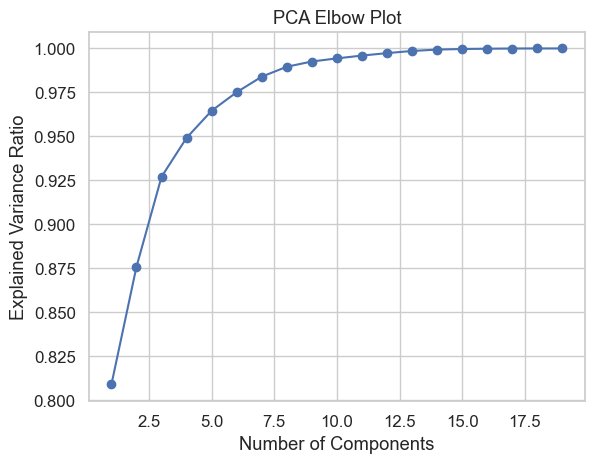

In [114]:
from sklearn.decomposition import PCA
drop_cols = [
    'GeoID', 'state', 'county', 'tract', 'zip_code',
    'LiveType', 'burden', 'majorHouseType', 'incomeLevel', 'Majority', 'filedEviction',
]
scaler = StandardScaler()
PCA_dataset = fullDataset.copy()

PCA_dataset.drop(columns=drop_cols, inplace=True)
PCA_dataset['medianIncome'] = scaler.fit_transform(PCA_dataset[['medianIncome']])

pca = PCA().fit(PCA_dataset)

cum_variance = np.cumsum(pca.explained_variance_ratio_)

# 3. Plot the Elbow (Scree) Plot
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         cum_variance , marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Elbow Plot')
plt.show()


In [115]:
opt_components = 7
pca_final = PCA(n_components=opt_components)

X_pca = pca_final.fit_transform(PCA_dataset)

reduced_data = pd.DataFrame(
    data=X_pca, 
    columns=[f'PCA_{i}' for i in range(1, opt_components+1)]
)

print(f'Reduced Clustering features: {reduced_data.shape[1]}  |  Tracts: {reduced_data.shape[0]}')

print(reduced_data.head())

Reduced Clustering features: 7  |  Tracts: 1533
      PCA_1     PCA_2     PCA_3     PCA_4     PCA_5     PCA_6     PCA_7
0  2.973776  0.262580  0.023417 -0.156116 -0.273909  0.423015  0.546861
1  1.095119 -0.361163 -0.111479 -0.186202 -0.153500  0.446570  0.674110
2  1.710008 -0.239166 -0.165650  0.047927 -0.054931  0.024217  0.100964
3  1.813216 -0.125705 -0.155255 -0.036898 -0.303203  0.071831  0.045129
4  1.813216 -0.125705 -0.155255 -0.036898 -0.303203  0.071831  0.045129


## 3. K-Means Clustering

We cluster census tracts using K-means to identify distinct socioeconomic groups. `medianIncome` is standardized via `StandardScaler`; all other features are already on [0, 1] as proportions. Categorical columns are excluded.

Optimal `k` is selected using four criteria:
- **Elbow** (WCSS): diminishing returns after the "elbow" point
- **Silhouette score**: higher = more compact, well-separated clusters
- **Calinski-Harabasz index**: higher = denser, better-separated clusters
- **Davies-Bouldin index**: lower = better separation


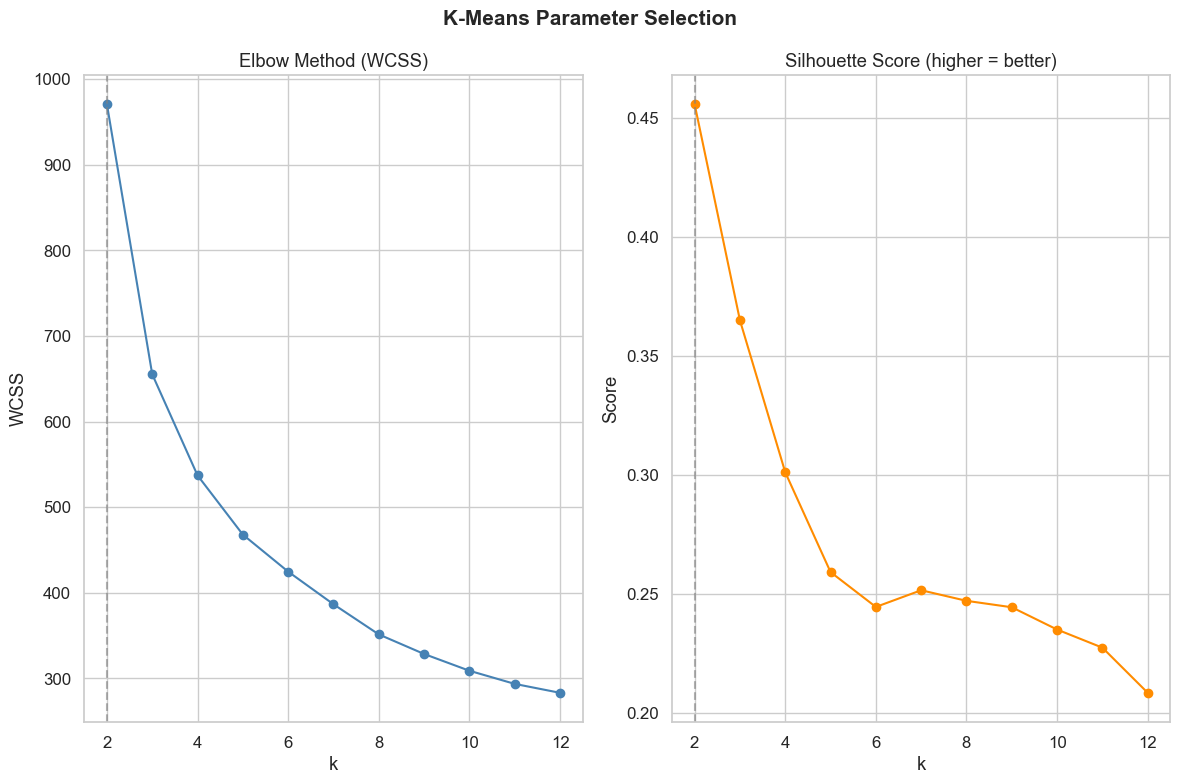

In [116]:
k_range = range(2, 13)
wcss, silhouette, ch_scores, db_scores = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(reduced_data)
    wcss.append(km.inertia_)
    silhouette.append(silhouette_score(reduced_data, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
fig.suptitle('K-Means Parameter Selection', fontsize=15, fontweight='bold')

axes[0].plot(k_range, wcss, 'o-', color='steelblue')
axes[0].set_title('Elbow Method (WCSS)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('WCSS')

axes[1].plot(k_range, silhouette, 'o-', color='darkorange')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')

for ax in axes.flat:
    ax.axvline(x=2, color='gray', linestyle='--', alpha=0.6, label='k=2')

plt.tight_layout()
plt.show()


**K selection rationale:** The elbow plot shows diminishing WCSS returns after k=2. Silhouette scores continue to degrade past k=2, confirming that further splits fragment naturally cohesive groups. We select **k=2**.


In [117]:
optimize_k = 2
km_final = KMeans(n_clusters=optimize_k, random_state=42, n_init=10)
fullDataset['cluster'] = km_final.fit_predict(reduced_data) + 1

print(fullDataset['cluster'].value_counts().sort_index())


cluster
1    1046
2     487
Name: count, dtype: int64


## 3. Cluster Profiles

How do the 2 clusters differ in income, eviction volume, racial composition, and rent burden?


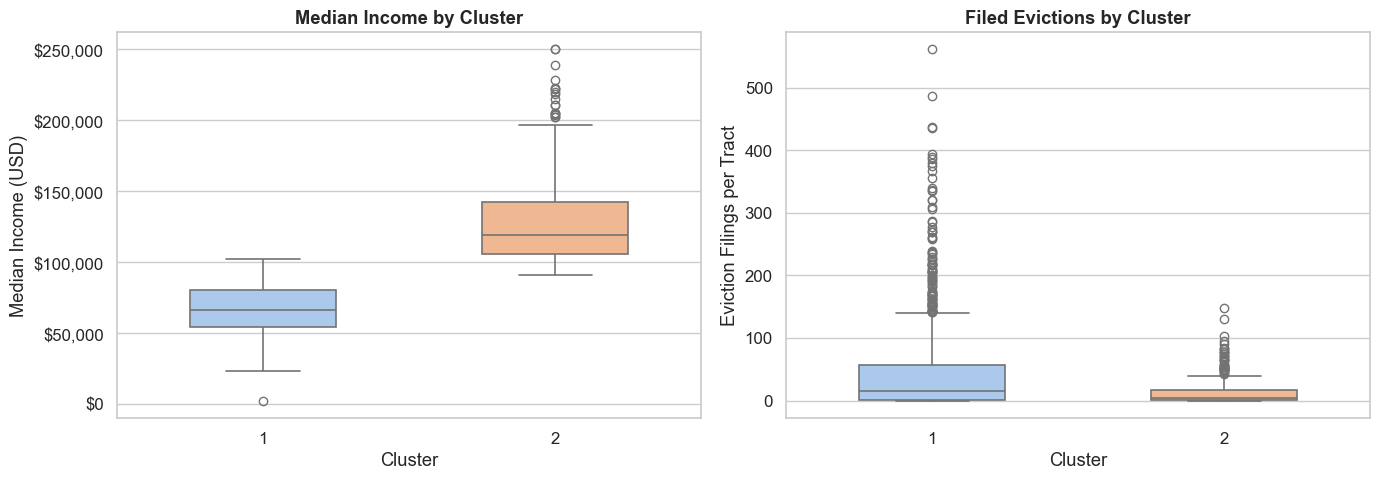

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=fullDataset, x='cluster', y='medianIncome',
    palette='pastel', width=0.5, linewidth=1.2, ax=axes[0]
)
axes[0].set_title('Median Income by Cluster', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Median Income (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.boxplot(
    data=fullDataset, x='cluster', y='filedEviction',
    palette='pastel', width=0.5, linewidth=1.2, ax=axes[1]
)
axes[1].set_title('Filed Evictions by Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Eviction Filings per Tract')

plt.tight_layout()
plt.show()


Boxplot indicates correlation between houshole median income and eviction count; cluster 1 has lower household income than cluster 2, cluster 1 has wider distribution than cluster 2. 

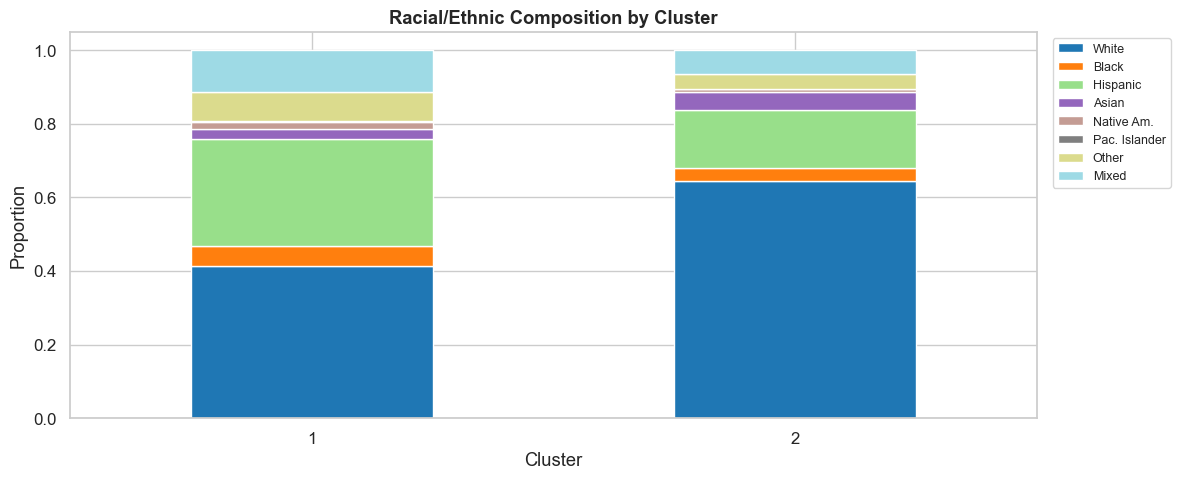

In [119]:
race_col_map = {
    'White Alone': 'White',
    'Black Alone': 'Black',
    'Hispanic or Latino': 'Hispanic',
    'Asian Alone': 'Asian',
    'American Indian or Alaska Native Alone': 'Native Am.',
    'Native Hawaiian or Pacific Islander Alone': 'Pac. Islander',
    'Some other race': 'Other',
    'Mixed race (exluding "Some other race")': 'Mixed',
}

race_avg = (
    fullDataset[['cluster'] + list(race_col_map.keys())]
    .rename(columns=race_col_map)
    .groupby('cluster').mean()
)
race_prop = race_avg.div(race_avg.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
race_prop.plot(kind='bar', stacked=True, colormap='tab20', ax=ax)
ax.set_title('Racial/Ethnic Composition by Cluster', fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Proportion')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


The analysis of ethnic composition reveals distinct demographic patterns across the clusters. Notably, Cluster 2 is predominantly composed of White residents (60%), which correlates with the higher median household income observed in our previous descriptive statistics.

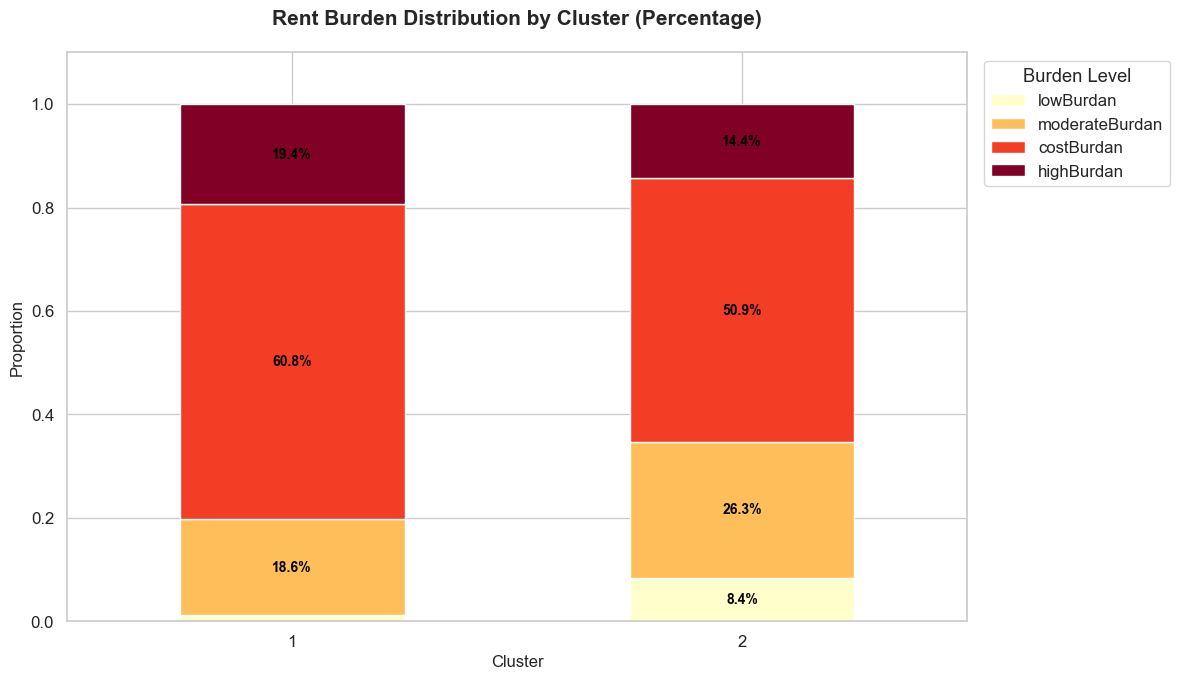

In [120]:
burden_order = ['lowBurdan', 'moderateBurdan', 'costBurdan', 'highBurdan']
burden_counts = pd.crosstab(fullDataset['cluster'], fullDataset['burden'])[burden_order]
burden_prop = burden_counts.div(burden_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 7))
burden_prop.plot(kind='bar', stacked=True, colormap='YlOrRd', ax=ax, edgecolor='white')

for c in ax.containers:
    labels = [f'{v.get_height()*100:.1f}%' if v.get_height() > 0.03 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10, fontweight='bold', color='black')

ax.set_title('Rent Burden Distribution by Cluster (Percentage)', fontweight='bold', fontsize=15, pad=20)
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.legend(title='Burden Level', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(0, 1.1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

According to the previous income analysis, both clusters have the highest ratio of Cost Burden (30-49% rent-to-income). This indicates that higher income levels in Cluster 2 correlate with better housing affordability, whereas Cluster 1 (with annual incomes under $100,000) generally experiences much higher rent burdens and lower financial resilience.

## 3b. Geographic Distribution Across Census Tracts

To understand the spatial context of eviction patterns, we map key variables across Maricopa County census tracts using Census TIGER/Line 2023 boundaries matched on `GeoID`. This surfaces whether clusters, income gradients, and rent burden are geographically concentrated or dispersed.

### Part 1: Geographic Segmentation by Tracts and Clusters

In [121]:
import geopandas as gpd
from matplotlib.patches import Patch

# Download TIGER/Line 2023 tract boundaries for Arizona (state FIPS 04), filter Maricopa County (013)
tiger_url = "https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_04_tract.zip"
tracts_geo = gpd.read_file(tiger_url)
tracts_geo = tracts_geo[tracts_geo['COUNTYFP'] == '013'].copy()

# Aggregate fullDataset to one row per tract (duplicate rows exist due to multiple zip codes per tract)
tract_agg = (
    fullDataset.groupby('GeoID').agg(
        filedEviction=('filedEviction', 'sum'),
        medianIncome=('medianIncome', 'first'),
        cluster=('cluster', 'first'),
        RenterOccupied=('RenterOccupied', 'first'),
        burden=('burden', 'first'),
        Majority=('Majority', 'first'),
    ).reset_index()
)

geo_df = tracts_geo.merge(tract_agg, left_on='GEOID', right_on='GeoID', how='left')
print(f"Maricopa County tracts: {len(geo_df)}  |  Tracts matched with data: {geo_df['GeoID'].notna().sum()}")


Maricopa County tracts: 1009  |  Tracts matched with data: 984


In [122]:
# Download TIGER/Line 2023 incorporated place (city/town) boundaries for Arizona
place_url = "https://www2.census.gov/geo/tiger/TIGER2023/PLACE/tl_2023_04_place.zip"
places_geo = gpd.read_file(place_url).to_crs(geo_df.crs)

# Clip to Maricopa County extent
minx, miny, maxx, maxy = geo_df.total_bounds
places_maricopa = places_geo.cx[minx:maxx, miny:maxy].copy()

# Assign each tract to the city containing its centroid (one city per tract)
tract_centroids = geo_df[['GEOID', 'geometry']].copy()
tract_centroids['geometry'] = geo_df.geometry.centroid

tract_city = gpd.sjoin(
    tract_centroids,
    places_maricopa[['NAME', 'geometry']],
    how='left', predicate='within'
)[['GEOID', 'NAME']].rename(columns={'NAME': 'city'})

geo_df = geo_df.merge(tract_city, on='GEOID', how='left')
geo_df['city'] = geo_df['city'].fillna('Unincorporated')

top_cities = geo_df['city'].value_counts()
print(top_cities.head(12).to_string())


city
Phoenix           373
Mesa              118
Unincorporated     58
Gilbert            57
Scottsdale         57
Chandler           57
Glendale           55
Tempe              41
Peoria             41
Surprise           26
Goodyear           24
Avondale           21


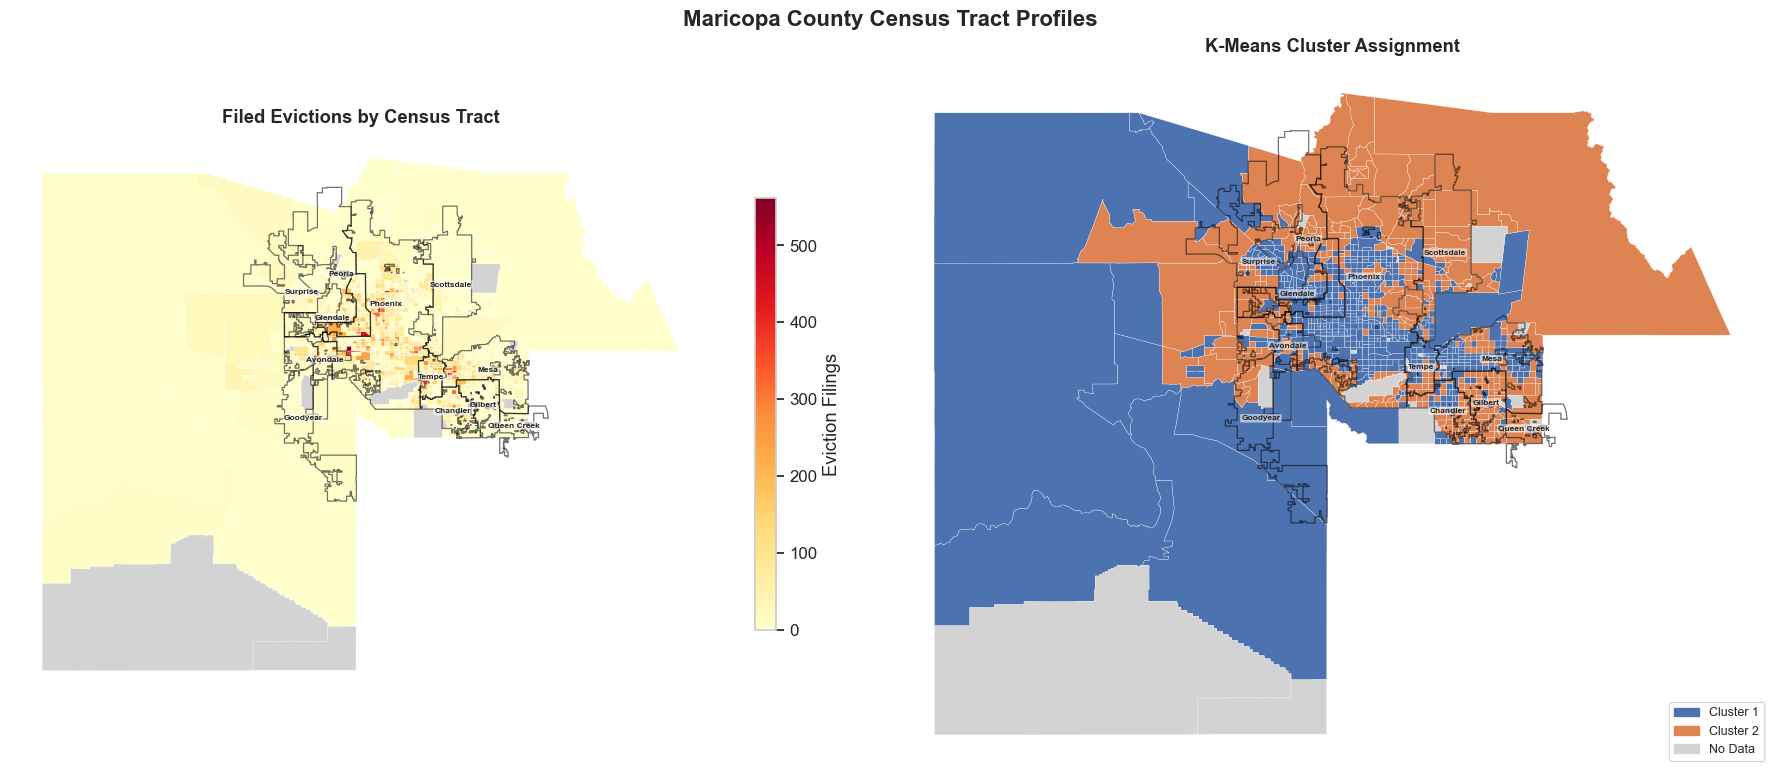

In [123]:
label_cities = [c for c in geo_df['city'].value_counts().head(13).index if c != 'Unincorporated']

city_dissolved = (
    geo_df[geo_df['city'].isin(label_cities)]
    .dissolve(by='city')
    .reset_index()[['city', 'geometry']]
)
city_dissolved['cx'] = city_dissolved.geometry.centroid.x
city_dissolved['cy'] = city_dissolved.geometry.centroid.y

city_outlines = places_maricopa[places_maricopa['NAME'].isin(label_cities)]

def _overlay_cities(ax):
    city_outlines.boundary.plot(ax=ax, color='black', linewidth=0.9, alpha=0.55)
    for _, row in city_dissolved.iterrows():
        ax.annotate(
            row['city'], xy=(row['cx'], row['cy']),
            fontsize=6, ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.55, ec='none'),
        )

cluster_colors = ['#4C72B0', '#DD8452']
geo_df['cluster_label'] = geo_df['cluster'].apply(
    lambda x: f'Cluster {int(x)}' if pd.notna(x) else None
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Maricopa County Census Tract Profiles', fontsize=16, fontweight='bold')

# Filed Evictions with city boundaries
geo_df.plot(
    column='filedEviction', ax=axes[0], cmap='YlOrRd',
    legend=True, legend_kwds={'label': 'Eviction Filings', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
    linewidth=0.2, edgecolor='white',
)
_overlay_cities(axes[0])
axes[0].set_title('Filed Evictions by Census Tract', fontweight='bold')
axes[0].axis('off')

# Cluster Assignment with city boundaries
for label, color in zip(['Cluster 1', 'Cluster 2'], cluster_colors):
    geo_df[geo_df['cluster_label'] == label].plot(ax=axes[1], color=color, linewidth=0.2, edgecolor='white')
geo_df[geo_df['cluster_label'].isna()].plot(ax=axes[1], color='lightgrey', linewidth=0.2, edgecolor='white')
_overlay_cities(axes[1])
legend_patches = [Patch(color=c, label=l) for c, l in zip(cluster_colors, ['Cluster 1', 'Cluster 2'])]
legend_patches.append(Patch(color='lightgrey', label='No Data'))
axes[1].legend(handles=legend_patches, loc='lower right', fontsize=9)
axes[1].set_title('K-Means Cluster Assignment', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Part 2: Number of Tracts by City and Cluster

To quantify how clusters distribute across municipalities, we count census tracts per city broken down by cluster assignment. This reveals whether certain cities are dominated by one cluster type, which has direct implications for where eviction risk is concentrated geographically.

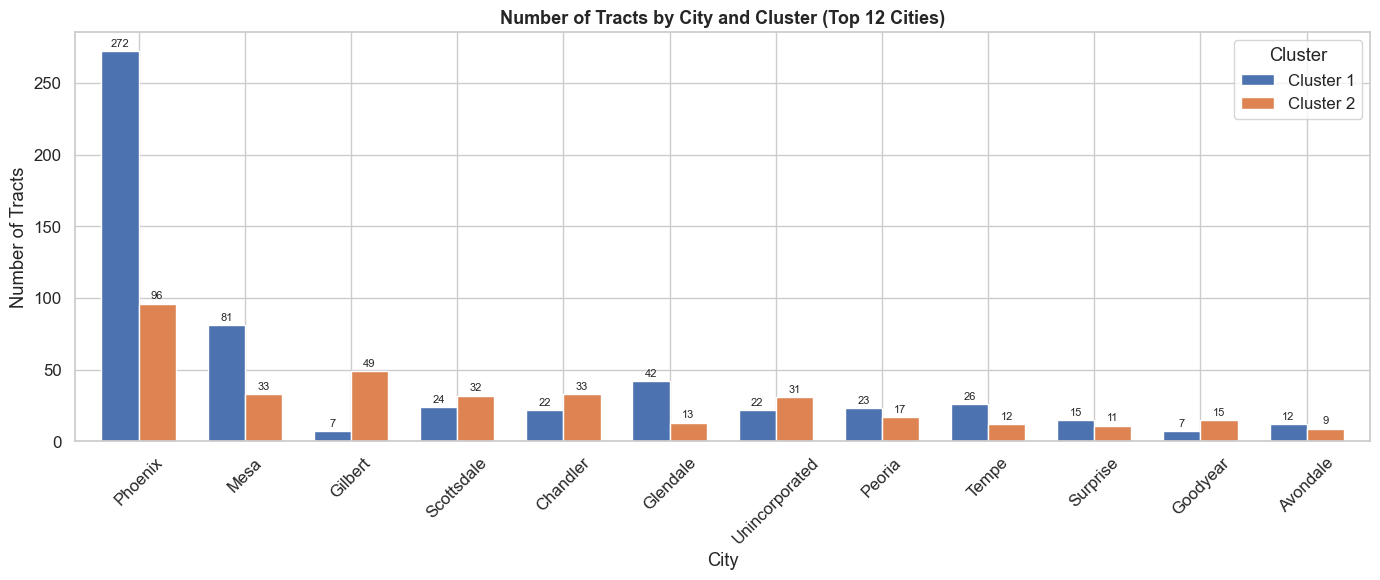

In [126]:
top_n = 12
tract_city_cluster = (
    geo_df[geo_df['GeoID'].notna() & geo_df['cluster'].notna()]
    .groupby(['city', 'cluster'])
    .size()
    .reset_index(name='tract_count')
)
tract_city_cluster['cluster'] = tract_city_cluster['cluster'].apply(lambda x: f'Cluster {int(x)}')

top_cities_list = (
    geo_df[geo_df['GeoID'].notna()]
    .groupby('city')
    .size()
    .nlargest(top_n)
    .index.tolist()
)

plot_data = tract_city_cluster[tract_city_cluster['city'].isin(top_cities_list)].copy()
pivot = plot_data.pivot(index='city', columns='cluster', values='tract_count').fillna(0).astype(int)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.7)
ax.set_title(f'Number of Tracts by City and Cluster (Top {top_n} Cities)', fontweight='bold', fontsize=13)
ax.set_xlabel('City')
ax.set_ylabel('Number of Tracts')
ax.legend(title='Cluster')
ax.tick_params(axis='x', rotation=45)
for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)
plt.tight_layout()
plt.show()

## 4. Collinearity Analysis

Compositional variables (proportions that sum to 1 within a group) create perfect or near-perfect collinearity. We identify these before modeling:

- **Tenure:** `OwnerOccupied + RenterOccupied = 1` → keep only `RenterOccupied`
- **Burden:** `lowBurdan + moderateBurdan + costBurdan + highBurdan ≈ 1` → drop `highBurdan` as reference
- **Housing structure:** four type proportions sum to ~1 → drop `mobile_other` as reference

We examine residual correlations and VIF on the reduced set.


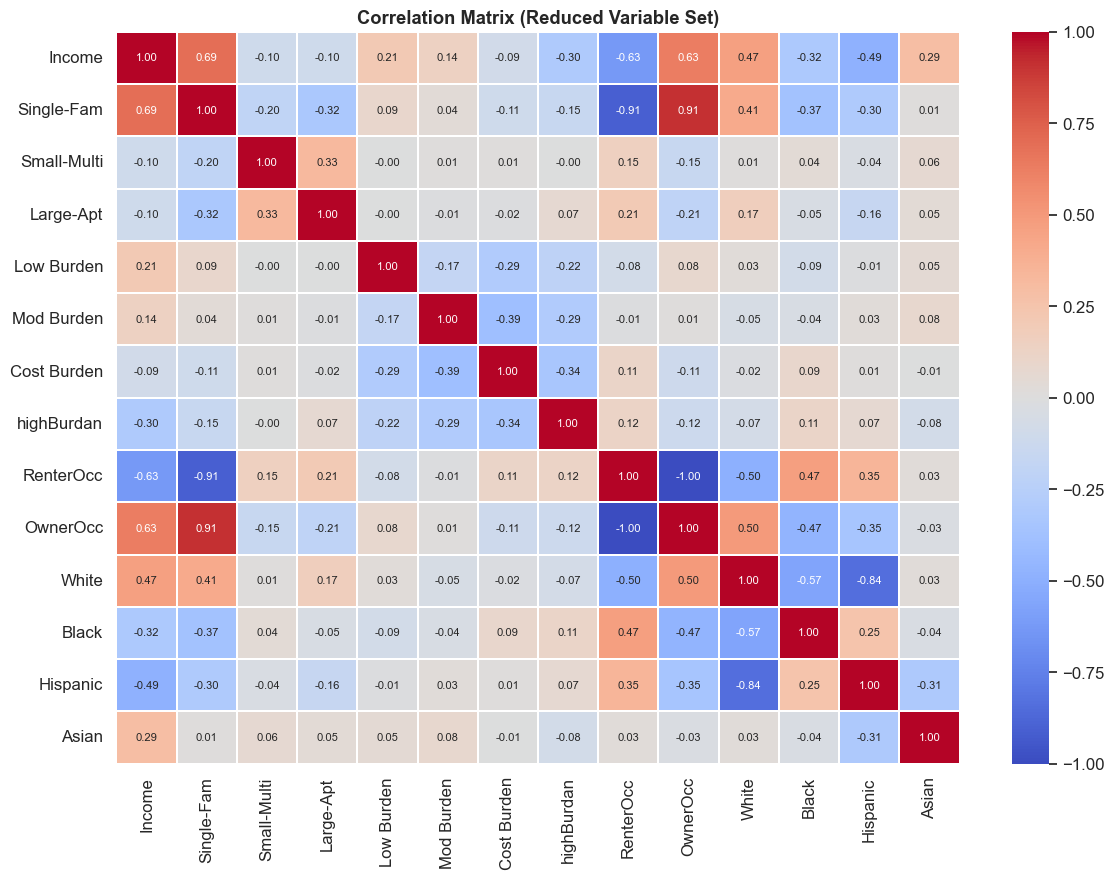

In [127]:
numeric_cols = [
    'medianIncome',
    'Single-family homes', 'Small multi-unit buildings (2-4 units)',
    'Larger apartment complexes (5+ units)',
    'lowBurdan', 'moderateBurdan', 'costBurdan','highBurdan',
    'RenterOccupied','OwnerOccupied',
    'White Alone', 'Black Alone', 'Hispanic or Latino', 'Asian Alone'
]
corr = fullDataset[numeric_cols].corr()

tick_labels = [
    'Income', 'Single-Fam', 'Small-Multi', 'Large-Apt',
    'Low Burden', 'Mod Burden', 'Cost Burden','highBurdan',
    'RenterOcc','OwnerOcc', 'White', 'Black', 'Hispanic', 'Asian'
]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot_kws={'size': 8},
    xticklabels=tick_labels, yticklabels=tick_labels,
    ax=ax
)
ax.set_title('Correlation Matrix (Reduced Variable Set)', fontweight='bold')
plt.tight_layout()
plt.show()


**Results:**
- Single-family home proportion and renter percentage are strongly negatively correlated.
- Renter proportion is strongly negatively correlated with median income.
- Hispanic proportion and White proportion are negatively correlated.
- Renter-occupied proportion is negatively correlated with owner-occupied proportion.
- Both renter and owner proportions are strongly correlated with White proportion.

In [128]:
vif_cols = [
    'medianIncome',
    'Single-family homes', 'Small multi-unit buildings (2-4 units)',
    'Larger apartment complexes (5+ units)',
    'lowBurdan', 'moderateBurdan', 'costBurdan','highBurdan',
    'RenterOccupied','OwnerOccupied',
    'White Alone', 'Black Alone', 'Hispanic or Latino', 'Asian Alone',
]
X_vif = fullDataset[vif_cols].dropna().copy()
X_vif = (X_vif - X_vif.mean()) / X_vif.std()

vif_df = pd.DataFrame({
    'Variable': vif_cols,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(len(vif_cols))
    ],
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_df['Flag'] = vif_df['VIF'].apply(lambda v: 'HIGH (>10)' if v > 10 else ('MOD (5-10)' if v > 5 else 'OK (<5)'))
display(vif_df)


,Variable,VIF,Flag
0,RenterOccupied,inf,HIGH (>10)
1,OwnerOccupied,inf,HIGH (>10)
2,White Alone,9.190982,MOD (5-10)
3,Single-family homes,8.123114,MOD (5-10)
4,Hispanic or Latino,7.272653,MOD (5-10)
5,costBurdan,3.102107,OK (<5)
6,medianIncome,2.960889,OK (<5)
7,moderateBurdan,2.697613,OK (<5)
8,highBurdan,2.669994,OK (<5)
9,Black Alone,2.486306,OK (<5)


**Collinearity findings:** Variables flagged with VIF > 5 are correlated with others in the same compositional group (e.g., housing type proportions). Each count regression model below focuses on one variable group at a time to avoid compounding collinearity. The final model retains only non-redundant predictors confirmed significant by both p-value and CI checks.

## 5. Count Regression Models

Since `filedEviction` is a non-negative count variable, we use count regression. We first fit a Poisson model, then test for overdispersion. If the variance substantially exceeds the mean, we switch to a Negative Binomial model, which adds a dispersion parameter to accommodate overdispersed counts. `cluster` is included as a fixed effect to control for cluster-level differences.

Predictors are selected based on two criteria:
1. **p-value < 0.05**
2. **95% CI does not contain zero** (confirms the effect direction is reliable)

In [129]:
mod = fullDataset.copy()

mod.rename(columns={
    'Single-family homes': 'single_family',
    'Small multi-unit buildings (2-4 units)': 'small_multi',
    'Larger apartment complexes (5+ units)': 'large_apartment',
    'Mobile homes, boats, RVs, etc.': 'mobile_other',
    'White Alone': 'white',
    'Black Alone': 'black',
    'Hispanic or Latino': 'latino',
    'American Indian or Alaska Native Alone': 'native_american',
    'Asian Alone': 'asian',
}, inplace=True)


In [130]:
descriptive_count = mod.groupby('cluster', as_index=False).agg( variance = ('filedEviction', 'var'), mean = ('filedEviction', 'mean'), total = ('cluster', 'count'))

descriptive_count['variance_mean_ratio'] = descriptive_count['variance'] / descriptive_count['mean']
descriptive_count

,cluster,variance,mean,total,variance_mean_ratio
0,1,4955.453313,44.551625,1046,111.229462
1,2,377.495450,12.887064,487,29.292588


The descriptive statistics table, grouped by cluster, shows that the variance is substantially larger than the mean in both clusters, violating the equidispersion assumption of the Poisson distribution. Therefore, we will use Negative Binomial regression to account for overdispersion.

In [131]:
poisson_eviction = smf.glm(
    formula='filedEviction ~ medianIncome + asian+black+white+small_multi+large_apartment+RenterOccupied+costBurdan+lowBurdan+moderateBurdan+highBurdan+C(cluster)',
    data=mod,
    family=sm.families.Poisson(),
).fit()
print('=== Poisson Model ===')
print(poisson_eviction.summary())


=== Poisson Model ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:          filedEviction   No. Observations:                 1533
Model:                            GLM   Df Residuals:                     1520
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -39502.
Date:                Tue, 05 May 2026   Deviance:                       72847.
Time:                        18:35:46   Pearson chi2:                 8.78e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           

In [132]:
nb_eviction = smf.glm(
    formula='filedEviction ~ medianIncome + asian+black+small_multi+large_apartment+RenterOccupied+costBurdan+lowBurdan+moderateBurdan+highBurdan+C(cluster)',
    data=mod, 
    family=sm.families.NegativeBinomial(alpha=1.0)
).fit()

print('=== Negative Binomial Model ===')
print(poisson_eviction.summary())

=== Negative Binomial Model ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:          filedEviction   No. Observations:                 1533
Model:                            GLM   Df Residuals:                     1520
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -39502.
Date:                Tue, 05 May 2026   Deviance:                       72847.
Time:                        18:35:46   Pearson chi2:                 8.78e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept 

## 6. Model comparison

### Log ratio test 

In [137]:
from scipy import stats
lr_stat = 2 * (nb_eviction.llf - poisson_eviction.llf)
p_val = stats.chi2.sf(lr_stat, df=1) 

print(f"LRT Statistic: {lr_stat:.4f}")
print(f"p-value: {p_val:.10f}")

LRT Statistic: 66058.6536
p-value: 0.0000000000


## 7. Interpretation

Coefficients from a Negative Binomial regression are on the log scale. Exponentiating them yields the **Incident Rate Ratio (IRR)**: the multiplicative change in expected eviction count for a one-unit increase in the predictor, holding all other variables constant. An IRR > 1 indicates more evictions; an IRR < 1 indicates fewer.

For proportion variables (scaled 0–1), IRRs are reported **per 10 percentage point (pp) increase** (i.e., `exp(coef × 0.10)`). For `medianIncome`, the IRR is reported **per $10,000 increase**. `C(cluster)[T.2]` is a binary indicator; its IRR is the direct exponentiated coefficient.

### Significant Predictors by IRR — Highest to Lowest (p < 0.05 AND CI excludes zero)

| Rank | Variable | Coef | IRR | Unit | % Change | Interpretation |
|---|---|---|---|---|---|---|
| 1 | `highBurdan` | 2.8996 | 1.336 | per 10 pp | +33.6% | Each 10 pp increase in severely burdened households (50%+) raises the eviction rate by 33.6% — the steepest burden effect |
| 2 | `costBurdan` | 2.6228 | 1.300 | per 10 pp | +30.0% | Each 10 pp increase in cost-burdened households (30–49%) raises the eviction rate by 30.0% |
| 3 | `moderateBurdan` | 2.3822 | 1.269 | per 10 pp | +26.9% | Each 10 pp increase in moderate-burden households (20–29%) raises the eviction rate by 26.9% |
| 4 | `lowBurdan` | 2.2910 | 1.258 | per 10 pp | +25.7% | Each 10 pp increase in low-burden households raises the eviction rate by 25.7% |
| 5 | `black` | 2.1796 | 1.244 | per 10 pp | +24.4% | Reflects underlying tenure and burden patterns; not interpreted as direct causation |
| 6 | `medianIncome` | −3.783e-06 | 0.963 | per $10,000 | −3.7% | Each $10,000 increase in median income is associated with a 3.7% lower eviction rate |
| 7 | `C(cluster)[T.2]` | −0.2750 | 0.760 | binary | −24.0% | Cluster 2 tracts have 24% fewer evictions than Cluster 1, controlling for all other predictors |

### Key findings

- **Cluster 2 tracts file 24% fewer evictions than Cluster 1** (IRR = 0.760), controlling for income, tenure, burden, race, and housing structure. Cluster 2 is characterized by higher median household income and a predominantly White demographic composition, suggesting that neighborhood-level socioeconomic advantage provides a protective effect beyond what individual predictors capture.

- **Median income has a modest but consistent protective effect** (IRR = 0.963 per $10,000 increase, −3.7%). While statistically reliable, the effect is small relative to rent burden, indicating that income growth alone is insufficient to meaningfully reduce eviction risk without also addressing housing cost pressure.

- **Rent burden is the strongest predictor, and the critical risk lies in compositional shifts toward higher burden tiers.** Because burden proportions within a tract sum to approximately 1, an increase in one tier necessarily displaces another. The marginal eviction rate increase from shifting 10 pp of households from low-burden to cost-burden is +3.4%; from low-burden to severely-burdened, +6.3%; and even a shift from cost-burden to severely-burdened alone adds +2.8%. This means the raw per-tier coefficients (+25.7% to +33.6%) overstate the isolated effect — what truly drives eviction risk is the **escalation of households out of lower burden tiers into cost-burdened or severely-burdened categories**, confirming housing cost pressure as the primary structural driver.

> A p-value below 0.05 alone is insufficient. We additionally require the 95% CI to exclude zero, ensuring the estimated IRR is not attributable to sampling variability.